<div style="background-color:#0B3C5D; padding:25px; border-radius:10px;">

![](https://raw.githubusercontent.com/wateraccounting/WaPORMOOC/main/images/banner_notebooks_WaPOR4Global.png)


<div style="text-align:center; margin-top:15px;">
<h3 style="color:#D9E6F2; margin-bottom:5px;">
<i>Module Three</i> – Topic 1a - <b>Long-Term Time Series Analysis of Iraq's Climate</b>
</h3>

<p style="color:white; margin-top:5px;">
<b>Estimated time:</b> 2 hours &nbsp; | &nbsp;
<b>Instructor:</b> Dr. Ahmed Elnaggar
</p>
</div>

</div>


---

### 📚 Course Information

| Item | Description |
|------|-------------|
| **Course** | MOOC — WaPOR for Global Challenges |
| **Module** | 3: WaPOR analyses |
| **Topic** | 1 of 3: Long-Term Time Series Analysis |
| **Focus** | Climatological variability of Rainfall & Reference ET |
| **Region** | Iraq — 18 Governorates |
| **Data** | Monthly observations (1980–present) |

---

### 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1. **Characterize** the climatological patterns of rainfall and reference ET across Iraq
2. **Compare** climate behaviour between selected northern, central, and southern governorates Iraq

---

### 📖 Table of Contents

1. Module 3 WaPOR analyses overview
2. Iraq's Water Landscape
3. Setup & Data Loading
4. Descriptive Statistics
5. Temporal Patterns — The Big Picture
6. The Clock of Seasons — Monthly Climatology
7. Spatial Patterns — Mapping the Differences
8. Summary

---

## 1. Module 3 WaPOR analyses overview

This notebook is the **first of three topics** in the module 'WaPOR analyses' of the MOOC on *"WaPOR for Global Challenges"*. Together, they tell a story from the national to the field level using Iraq as a case study:

> 🌍 **Topic 1 — The Wide Lens (This Notebook):**
> We begin at the **country level**, analysing long-term rainfall and reference evapotranspiration across all **18 governorates** of Iraq. This establishes the climatic baseline: *Where is it wet? Where is it dry? Is the climate changing?*

> 🏙️ **Topic 2 — Zooming Into Erbil (Notebook can be found here):**
> We narrow our focus to a single governorate — **Erbil** — using high-resolution **FAO WaPOR data**. Here we analyse drought dynamics, water productivity, and water-use patterns and their interactions at much finer spatial and temporal detail.

> 🌾 **Topic 3 — Down to the Field (Notebook can be found here):**
> Finally, we zoom to the **field level**, selecting ~13 centre-pivot irrigated fields near Erbil. We apply **ARIMA and SARIMAX forecasting models** to predict water consumption, comparing performance across individual fields.

Each step builds on the previous one — understanding the country’s climate helps interpret what we see in Erbil, and understanding Erbil helps frame why field-level forecasting matters for operational water management.

---

## 2. Iraq’s Water Landscape

Iraq, the land of **Mesopotamia** ("between the rivers"), has been shaped by the Tigris and Euphrates for millennia. But today, this cradle of civilisation faces an unprecedented water crisis affecting its agricultural sector:

| Challenge | Description |
|-----------|-------------|
| 🌡️ **Rising temperatures** | Average temperatures have increased by ~1.5°C since the 1970s |
| 🌧️ **Declining rainfall** | 10–20% reduction in annual precipitation in some regions |
| 🏗️ **Upstream dams** | Turkey and Iran’s dam construction has reduced river flows |
| 🌾 **Agricultural demand** | ~80% of water use goes to agriculture |
| 📈 **Population growth** | Doubling since 1990, increasing water demand |


---


> 💡 **Key Question:** *What is the spatio-temporal variability of the climate in Iraq?*



---

## 3. Setting up the environment & Load data for analyses

### Required Packages

We use standard Python data-science libraries, such as `geopandas` for spatial mapping.

In [36]:
# =============================================================================
# INSTALL & IMPORT PACKAGES
# =============================================================================

# Uncomment to install if needed:
!pip install numpy pandas matplotlib seaborn scipy --quiet
!pip install geopandas --quiet         # Optional, for map visualisation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
import os
import warnings
from datetime import datetime

# --- Configuration ---
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [14, 7]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"\n\u2705 Setup complete \u2014 Pandas {pd.__version__}, NumPy {np.__version__}")
print(f"\U0001f4c5 Analysis date: {datetime.now().strftime('%Y-%m-%d')}")


✅ Setup complete — Pandas 2.2.2, NumPy 2.0.2
📅 Analysis date: 2026-04-08


### Data Files

Place the following data* files in a new folder called `data/` (source of data: AgERA5 for the period 1980-2025):

| File | Description |
|------|-------------|
| `AgERA5-PCP-M_mm.csv` | Monthly rainfall (mm/month) for 18 governorates of Iraq|
| `AgERA5-RET-M_mm.csv` | Monthly reference ET (mm/month) for 18 governorates of Iraq |
| `irq_admin1.geojson` | Boundaries of the 18 Iraqi governorates |

**Expected CSV format:** First column = date (`DD/MM/YYYY`), remaining columns = governorate names.

*Instructions on how to download the required data is provided in this [Notebook](notebook link).

In [3]:
# =============================================================================
# CREATE INPUT AND OUTPUT FOLDERS
# =============================================================================
data_folder = 'data'
os.makedirs(data_folder, exist_ok=True)

output_folder = 'output_data'
os.makedirs(output_folder, exist_ok=True)

First the format of the data needs to be defined. In the following script, the CSV file is read from a file path, different dates formats are recognised and the first column is idenfitied as date and it is sorted.

In [4]:
# =============================================================================
# DEFINING DATA FORMAT
# =============================================================================

def load_governorate_data(filepath, name='dataset'):
    """
    Load monthly governorate-level data from CSV.
    Expects: first column = date, remaining columns = governorates.
    """
    # Added 'delimiter=';'' to handle semicolon-separated CSVs
    df = pd.read_csv(filepath, delimiter=';')
    date_col = df.columns[0]

    # Parse dates (try multiple formats)
    for fmt in ['%d/%m/%Y', '%m/%d/%Y', '%Y-%m-%d', '%Y/%m/%d']:
        try:
            df[date_col] = pd.to_datetime(df[date_col], format=fmt)
            break
        except (ValueError, TypeError):
            continue
    else:
        df[date_col] = pd.to_datetime(df[date_col], dayfirst=True)

    df.set_index(date_col, inplace=True)
    df.index.name = 'date'
    df = df.sort_index()

    # Ensure numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    print(f"\U0001f4c4 {name}: {df.shape[0]} months × {df.shape[1]} governorates")
    print(f"   Period: {df.index.min().strftime('%b %Y')} — {df.index.max().strftime('%b %Y')}")
    return df


The `load_governorate_data` function is run using the following script for each data file:

Check if for each data set you have data for the entire period.

In [5]:
# --- Load Rainfall ---
rainfall_file = os.path.join(data_folder, '/content/data/AgERA5-PCP-M_mm.csv')
if os.path.exists(rainfall_file):
    df_rain = load_governorate_data(rainfall_file, name='Rainfall')
else:
    raise FileNotFoundError(f"Rainfall file not found: {rainfall_file}")

# --- Load Reference ET ---
refet_file = os.path.join(data_folder, '/content/data/AgERA5-RET-M_mm.csv')
if os.path.exists(refet_file):
    df_ret = load_governorate_data(refet_file, name='Reference ET')
else:
    raise FileNotFoundError(f"Reference ET file not found: {refet_file}")

# --- Governorate list ---
governorates = df_rain.columns.tolist()
n_gov = len(governorates)
print(f"\n\U0001f4cd {n_gov} governorates detected: {governorates}")

📄 Rainfall: 552 months × 18 governorates
   Period: Jan 1980 — Dec 2025
📄 Reference ET: 552 months × 18 governorates
   Period: Jan 1980 — Dec 2025

📍 18 governorates detected: ['Al-Anbar', 'Al-Basrah', 'Al-Muthanna', 'Al-Najaf', 'Al-Qadissiya', 'Al-Sulaymaniyah', 'Babil', 'Baghdad', 'Diyala', 'Duhok', 'Erbil', 'Kerbala', 'Kirkuk', 'Maysan', 'Ninewa', 'Salah Al-Din', 'Thi Qar', 'Wassit']


# Inspect the data

The previous script checks the data that is contained in the files. Inspect if the data contains information for all the 18 governorates and the period 1980-2025.

If all is in order, now lets have a look at the data!

The precipitation data file is loaded into the script as `df_rain/`. To view the content of the file, run the next cell.

***Exercise***: Can you also inspect the Reference ET data file?

HINT: Inspect the code in the previous cell and identify the name of the dataframe which contains the reference ET data.

In [6]:
# =============================================================================
# DATA INSPECTION
# =============================================================================

print("RAINFALL DATA \u2014 First 12 Months")
display(df_rain.head(12))


RAINFALL DATA — First 12 Months


,Al-Anbar,Al-Basrah,Al-Muthanna,Al-Najaf,Al-Qadissiya,Al-Sulaymaniyah,Babil,Baghdad,Diyala,Duhok,Erbil,Kerbala,Kirkuk,Maysan,Ninewa,Salah Al-Din,Thi Qar,Wassit
date,,,,,,,,,,,,,,,,,,
1980-01-01,11.63,19.76,11.80,7.15,9.92,106.33,11.10,14.34,35.04,93.52,91.91,8.19,35.05,36.22,34.06,16.70,17.18,26.79
1980-02-01,56.31,80.02,78.00,59.85,64.76,146.25,72.09,74.64,92.57,118.25,117.30,76.95,88.31,130.04,86.88,73.87,94.04,87.87
1980-03-01,11.83,16.79,10.32,14.31,23.77,167.32,14.14,16.86,63.85,230.16,178.85,9.76,74.90,46.09,88.12,26.04,21.89,39.52
1980-04-01,12.16,2.03,2.11,3.30,4.98,122.62,7.36,13.85,21.50,239.74,165.96,6.06,51.55,4.36,92.96,22.47,4.12,7.77
1980-05-01,0.42,0.27,0.62,0.26,1.18,17.25,0.19,0.38,1.88,61.06,24.54,0.13,2.78,2.10,8.69,1.26,1.35,2.11
1980-06-01,0.00,0.00,0.00,0.00,0.00,2.16,0.00,0.00,0.01,4.31,3.07,0.00,0.29,0.00,0.81,0.06,0.00,0.00
1980-07-01,0.00,0.03,0.00,0.00,0.00,0.10,0.01,0.00,0.00,1.80,1.19,0.00,0.00,0.01,0.04,0.00,0.02,0.00
1980-08-01,0.00,0.00,0.00,0.00,0.00,0.83,0.00,0.00,0.00,1.13,1.16,0.00,0.04,0.00,0.02,0.00,0.00,0.00
1980-09-01,0.03,0.00,0.00,0.00,0.00,0.22,0.00,0.00,0.01,1.17,0.74,0.00,0.07,0.00,0.06,0.06,0.00,0.00


# Quick check for completeness of the rainfall data

The following cell will check if the data has any missing values.

***Exercise:*** Can you check if the Reference ET data is also complete?

In [7]:
# Quick completeness check
print("\n\U0001f4ca Data Completeness:")
rain_missing = df_rain.isnull().sum()

if rain_missing.sum() == 0:
    print("   Rainfall:     \u2705 No missing values")
else:
    print(f"   Rainfall:     \u26a0\ufe0f {rain_missing.sum()} missing values")
    print(rain_missing[rain_missing > 0])


📊 Data Completeness:
   Rainfall:     ✅ No missing values


---

## 4. Temporal Patterns — The Big Picture

> *"Let’s unroll the tape and see four decades of climate history."*

We start with plotting the raw time series. Run the cell below to visualise the monthly rainfall for all governorates.

***Exercise:*** update the code to visualise the Reference ET data as well.

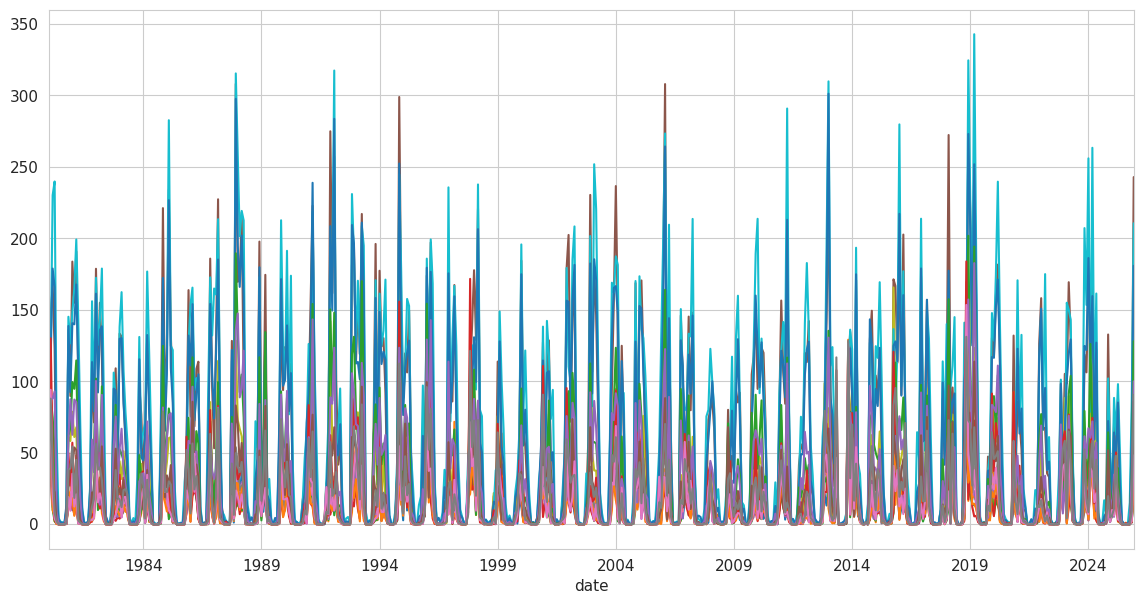

In [8]:
df_rain.plot(legend=False);


It is very difficult to interpret the results using this graph.

To present the timeseries of rainfall for all 18 governorates each in a separate graph, run the cell below.

***Exercise***: Copy the code into a new code cell to create the Reference ET graphs. Read each line of the code and change the values and see how it changes the graphs.

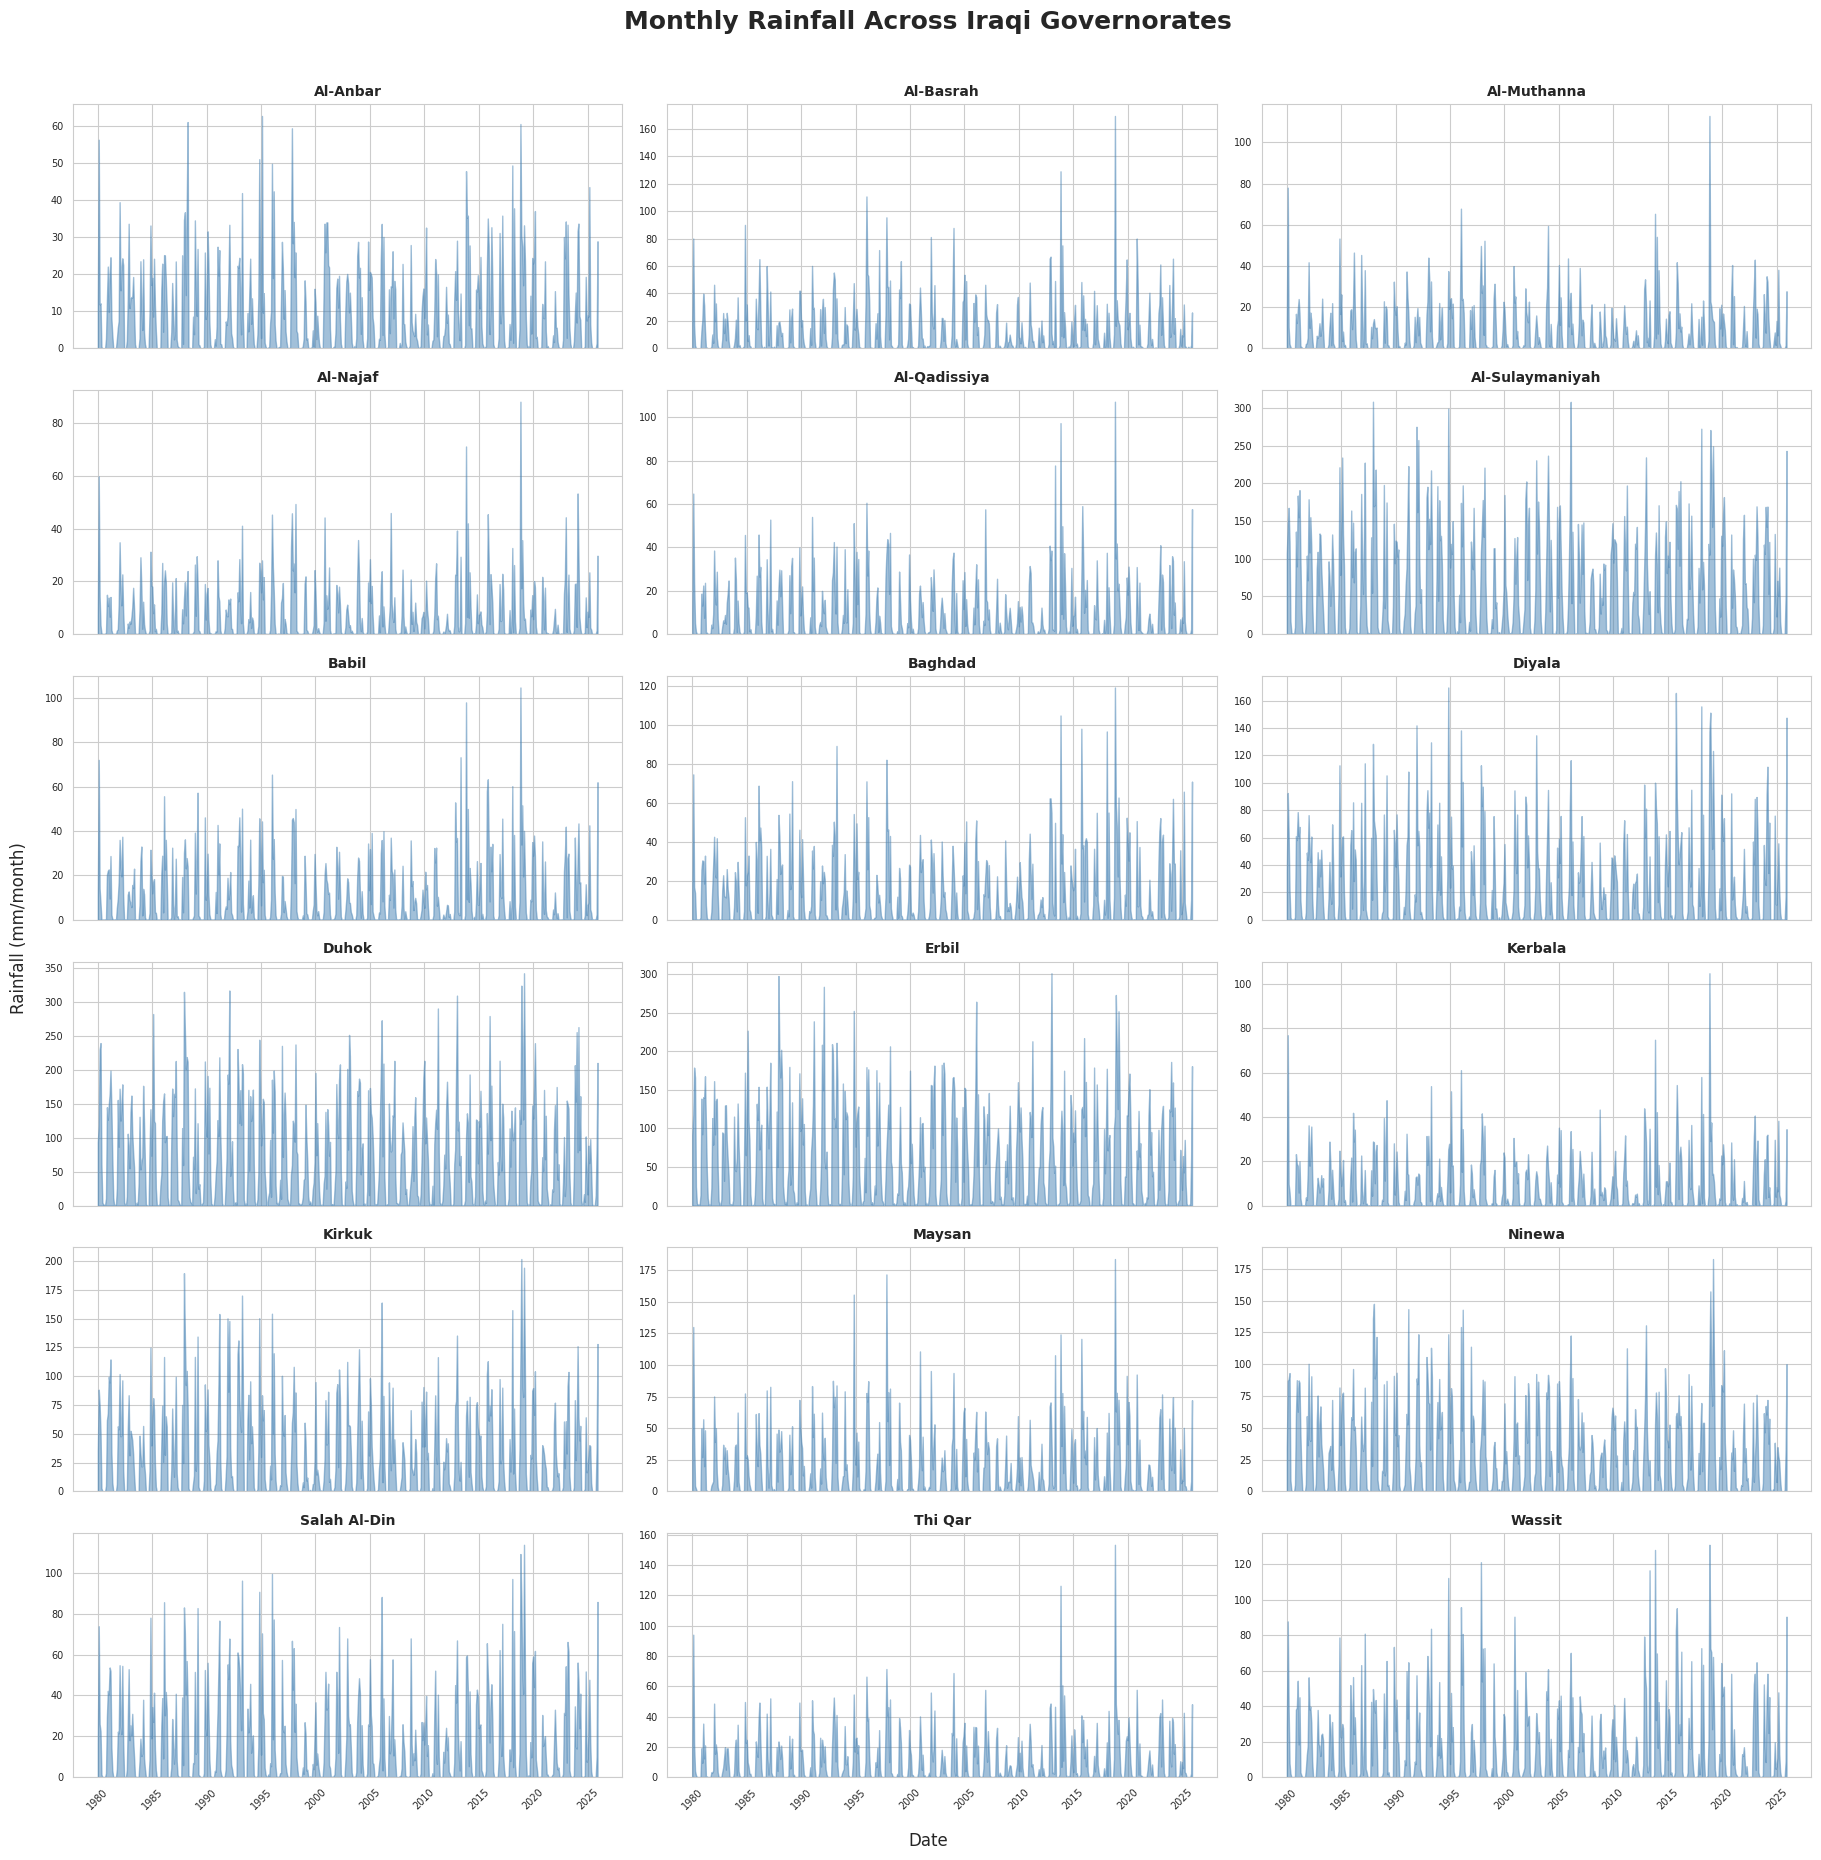

In [9]:
# =============================================================================
# RAINFALL TIME SERIES - ALL GOVERNORATES (Small Multiples)
# =============================================================================

n_cols = 3
n_rows = (n_gov + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows), sharex=True)
fig.suptitle('Monthly Rainfall Across Iraqi Governorates',
             fontsize=18, fontweight='bold', y=1.01)

axes_flat = axes.flatten()

for idx, gov in enumerate(governorates):
    ax = axes_flat[idx]
    ax.fill_between(df_rain.index, 0, df_rain[gov], color='steelblue', alpha=0.5)
    #ax.plot(df_rain[gov].rolling(12).mean(), color='darkblue', linewidth=1.2,
           # label='12-month MA')
    ax.set_title(gov, fontsize=10, fontweight='bold')
    ax.set_ylim(bottom=0)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

# Remove empty subplots
for idx in range(n_gov, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.text(0.5, -0.01, 'Date', ha='center', fontsize=12)
fig.text(-0.01, 0.5, 'Rainfall (mm/month)', va='center',
         rotation='vertical', fontsize=12)
plt.tight_layout()
plt.show()

---

## 5. Descriptive Statistics

> *"Before we tell the story, let’s meet the characters."*

Each governorate has its own climate personality — some consistently wet, others bone-dry, some wildly variable from year to year. Descriptive statistics help us characterise these personalities before we look at trends or anomalies. In the following cell the most common statistics are calculated. `('YE').sum/` corresponds to summarising the data annually.

NOTE: If the data is provided in daily timesteps, this script can also be used to create monthly timeseries using `('ME').sum/` or from sub-daily to daily timeseries using `('DE').sum/`.




In [10]:
# =============================================================================
# DESCRIPTIVE STATISTICS (ANNUAL TOTALS)
# =============================================================================

# Aggregate to annual totals
rain_annual = df_rain.resample('YE').sum()

# --- Rainfall statistics ---
rain_stats = pd.DataFrame({
    'Mean (mm/yr)': rain_annual.mean(),
    'Std (mm/yr)':  rain_annual.std(),
    'CV (%)':       (rain_annual.std() / rain_annual.mean()) * 100,
    'Min (mm/yr)':  rain_annual.min(),
    'Max (mm/yr)':  rain_annual.max(),
    'Median (mm/yr)': rain_annual.median(),
    'Skewness':     rain_annual.skew()
}).round(1)

print("="*70)
print("ANNUAL RAINFALL STATISTICS BY GOVERNORATE")
print("="*70)
display(rain_stats.sort_values('Mean (mm/yr)', ascending=False))

ANNUAL RAINFALL STATISTICS BY GOVERNORATE


,Mean (mm/yr),Std (mm/yr),CV (%),Min (mm/yr),Max (mm/yr),Median (mm/yr),Skewness
Duhok,879.50,190.20,21.60,502.50,1262.90,887.80,0.10
Al-Sulaymaniyah,746.40,177.50,23.80,374.80,1084.40,764.30,-0.10
Erbil,727.80,166.20,22.80,399.40,1033.60,725.60,0.10
Kirkuk,379.70,119.70,31.50,148.00,654.30,368.20,0.40
Ninewa,352.70,107.20,30.40,156.50,598.70,339.10,0.40
Diyala,304.20,94.00,30.90,102.60,596.90,300.60,0.50
Maysan,220.30,77.00,34.90,86.90,420.40,209.70,0.40
Salah Al-Din,201.40,66.30,32.90,68.40,402.70,196.80,0.70
Wassit,199.00,66.00,33.10,68.40,380.40,188.90,0.60
Baghdad,157.00,55.70,35.50,61.30,360.30,155.50,1.20


You can also save the data frame as csv file by running the following code.

```
from pathlib import Path
filepath = Path("/content/output_data/rain_annual.csv")
rain_annual.to_csv(filepath)

```

In [11]:
from pathlib import Path
filepath_rain_annual = Path("/content/output_data/rain_annual.csv")
rain_annual.to_csv(filepath_rain_annual)
filepath_rain_stats = Path("/content/output_data/rain_stats.csv")
rain_stats.to_csv(filepath_rain_stats)

You can interogate the `rain_stats` using functions like the ones below.

***Excercise*** Find out which governorate has the lowest mean annual rainfall? Find out the amount and standard deviation.

In [12]:
print(rain_stats['Mean (mm/yr)'].idxmax())
print(rain_stats['Mean (mm/yr)'].max())

Duhok
879.5


Repeat the previous steps and calculate the statistics for the reference ET data.


In [ ]:
# =============================================================================
# DESCRIPTIVE STATISTICS (ANNUAL TOTALS)
# =============================================================================

# Aggregate to annual totals

# --- Reference ET statistics ---



# Quiz question:

Which governorate has the highest annual RET and what is the value (in mm/year - no digits)?
Which governorate has the lowest annual RET and what is the value (in mm/year- no digits)

Write down the answers, you need it for the quiz!

Lets plot the rainfall stations in one horizontal bar chart in ascending order. Play around with the settings to get the graph the way you like or need it for your report or presentation.  

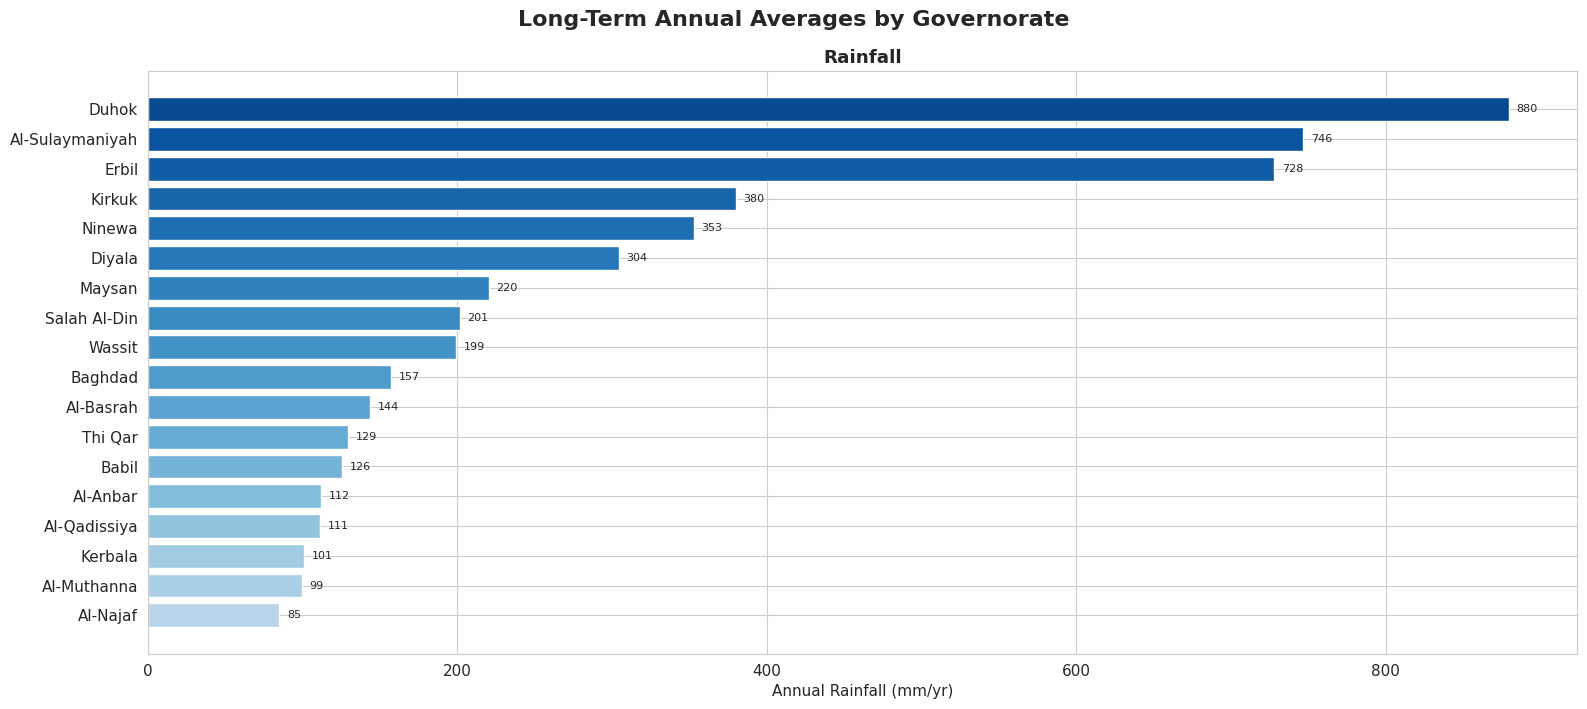

In [14]:
# =============================================================================
# ANNUAL TOTALS — ORGANISED IN ASCENDING ORDER
# =============================================================================

sorted_govs_rain = rain_stats.sort_values('Mean (mm/yr)', ascending=True).index.tolist()

fig, ax = plt.subplots(1, 1, figsize=(16, max(6, n_gov * 0.4)))
fig.suptitle('Long-Term Annual Averages by Governorate',
             fontsize=16, fontweight='bold')

# --- Rainfall ---
colors_rain = plt.cm.Blues(np.linspace(0.3, 0.9, n_gov))
bars1 = ax.barh(sorted_govs_rain,
                 rain_stats.loc[sorted_govs_rain, 'Mean (mm/yr)'],
                 color=colors_rain, edgecolor='white')
ax.set_xlabel('Annual Rainfall (mm/yr)')
ax.set_title('Rainfall', fontweight='bold')
for bar, val in zip(bars1, rain_stats.loc[sorted_govs_rain, 'Mean (mm/yr)']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}', va='center', fontsize=8)


plt.tight_layout()
plt.show()


---

## 6. The Clock of Seasons — Monthly Climatology

> *"Every year, the same rhythm: rain falls in winter, the sun blazes in summer, and the land oscillates between brief abundance and long thirst."*

Monthly climatology — the average value for each month across all years — reveals the **seasonal heartbeat** of Iraq’s climate. This is the background pattern against which all variability and change are measured. First lets calculate the mean monthly values and assign the names of the month to the first column (index).

In [35]:
# =============================================================================
# MONTHLY CLIMATOLOGY
# =============================================================================

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Compute monthly climatology
rain_clim = df_rain.groupby(df_rain.index.month).max()
rain_clim.index = month_names

print(rain_clim)

     Al-Anbar  Al-Basrah  Al-Muthanna  Al-Najaf  Al-Qadissiya  \
Jan     49.81     110.72        67.81     45.35         60.53   
Feb     62.73      80.02        78.00     59.85         64.76   
Mar     43.52      71.63        52.22     49.37         52.75   
Apr     61.08      46.04        32.45     41.12         40.31   
May     22.47      49.09        23.23     29.34         77.70   
Jun      1.38       1.88         0.59      0.41          0.32   
Jul      0.14       1.21         0.45      0.07          0.19   
Aug      0.62       1.56         0.26      0.31          1.15   
Sep      3.70       1.90         1.64      2.32          4.19   
Oct     27.88      48.33        30.51     32.74         25.98   
Nov     60.55     169.45       112.85     88.21        107.12   
Dec     35.28      81.15        40.45     45.95         57.60   

     Al-Sulaymaniyah  Babil  Baghdad  Diyala  Duhok  Erbil  Kerbala  Kirkuk  \
Jan           236.54  65.45    71.06  138.25 309.77 301.12    61.17  154.27

Lets visualise this data into bar charts using the script below.

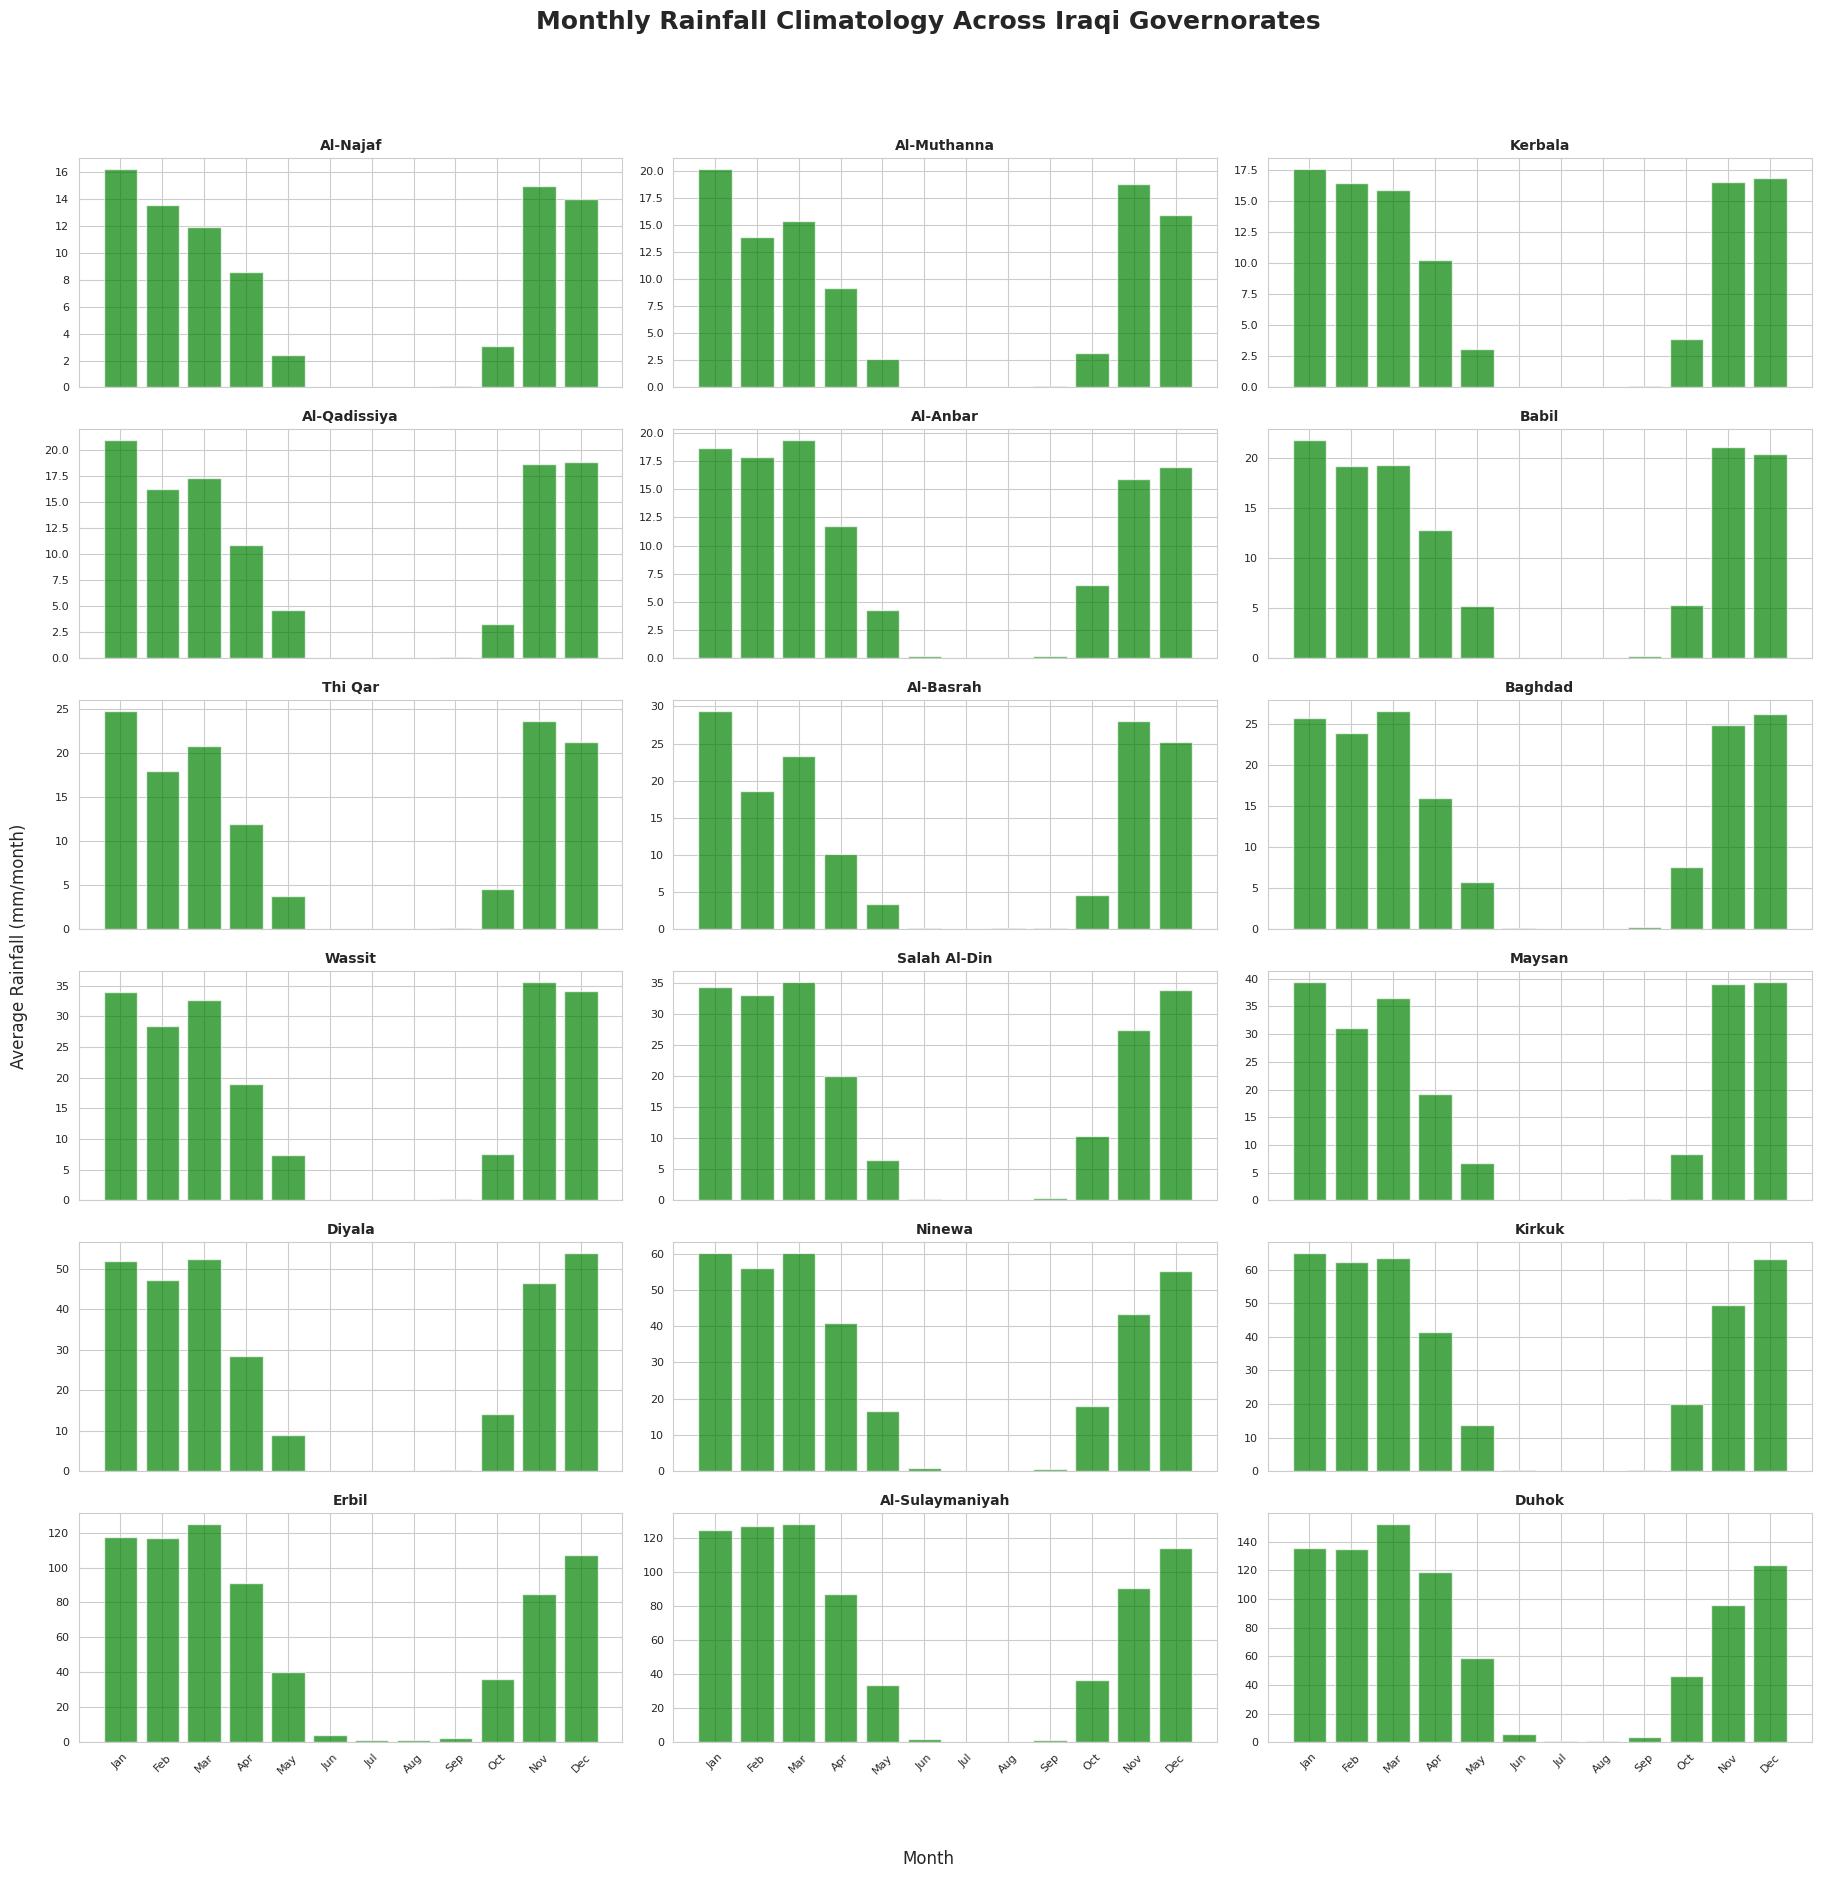

In [33]:
# =============================================================================
# MONTHLY RAINFALL - VERTICAL BAR GRAPHS (Small Multiples)
# =============================================================================
sorted_govs_rain = rain_stats.sort_values('Mean (mm/yr)', ascending=True).index.tolist()

n_cols = 3 # Number of columns for subplots
n_rows = (n_gov + n_cols - 1) // n_cols # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3 * n_rows), sharex=True, sharey=False)
fig.suptitle('Monthly Rainfall Climatology Across Iraqi Governorates',
             fontsize=18, fontweight='bold', y=1.02)

axes_flat = axes.flatten()

for idx, gov in enumerate(sorted_govs_rain):
    ax = axes_flat[idx]
    ax.bar(rain_clim.index, rain_clim[gov], color='green', alpha=0.7)
    ax.set_title(gov, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_ylim(bottom=0) # Ensure y-axis starts from 0

# Remove empty subplots if any
for idx in range(len(sorted_govs_rain), len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.text(0.5, -0.01, 'Month', ha='center', fontsize=12)
fig.text(-0.01, 0.5, 'Average Rainfall (mm/month)', va='center',
         rotation='vertical', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

There is a lot of information presented in the 18 graphs, a heatmap will help visualise the results.

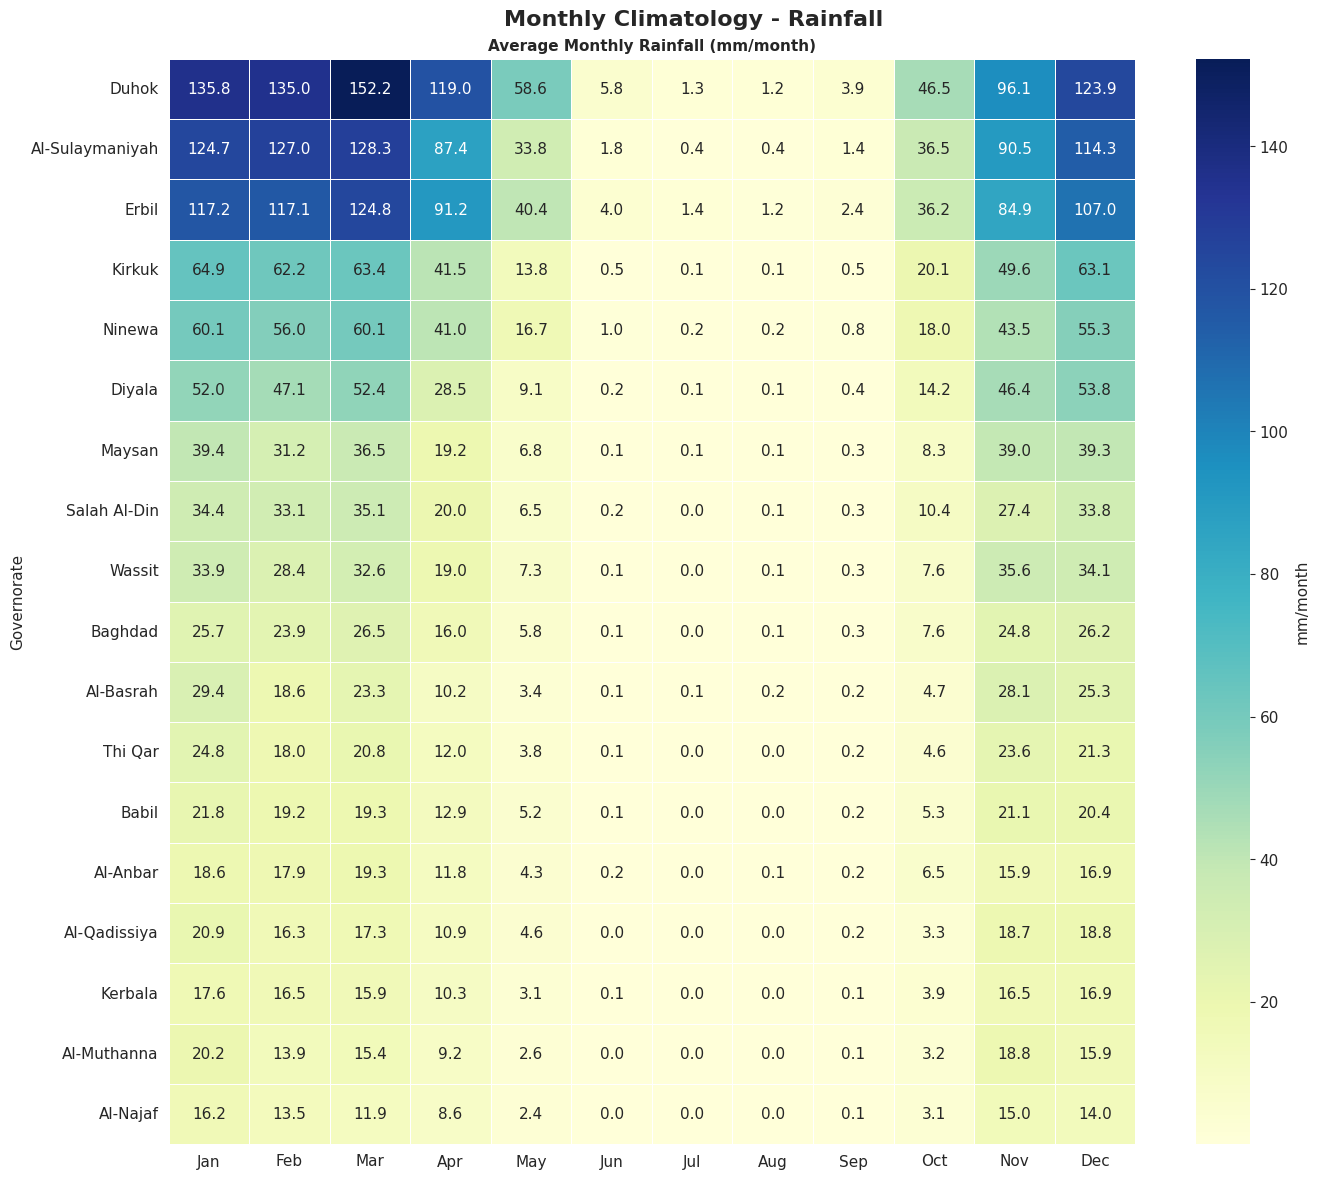

In [26]:
# =============================================================================
# MONTHLY RAINFALL HEATMAP
# =============================================================================

# Sort governorates by annual rainfall (wettest first)
sorted_govs = rain_stats.sort_values('Mean (mm/yr)', ascending=False).index.tolist()

fig, axes = plt.subplots(1, 1, figsize=(max(14, n_gov * 0.4), 12))
fig.suptitle('Monthly Climatology - Rainfall',
             fontsize=16, fontweight='bold')

# --- Rainfall Heatmap ---
sns.heatmap(rain_clim[sorted_govs].T, ax=axes, cmap='YlGnBu',
            annot=True, fmt='.1f', linewidths=0.5,
            cbar_kws={'label': 'mm/month'})
axes.set_title('Average Monthly Rainfall (mm/month)', fontsize=11, fontweight='bold')
axes.set_ylabel('Governorate')
axes.set_xlabel('')

plt.tight_layout()
plt.show()

To compare the seasonal rainfall patterns of three selected governorates. Create a line graph using the script below.

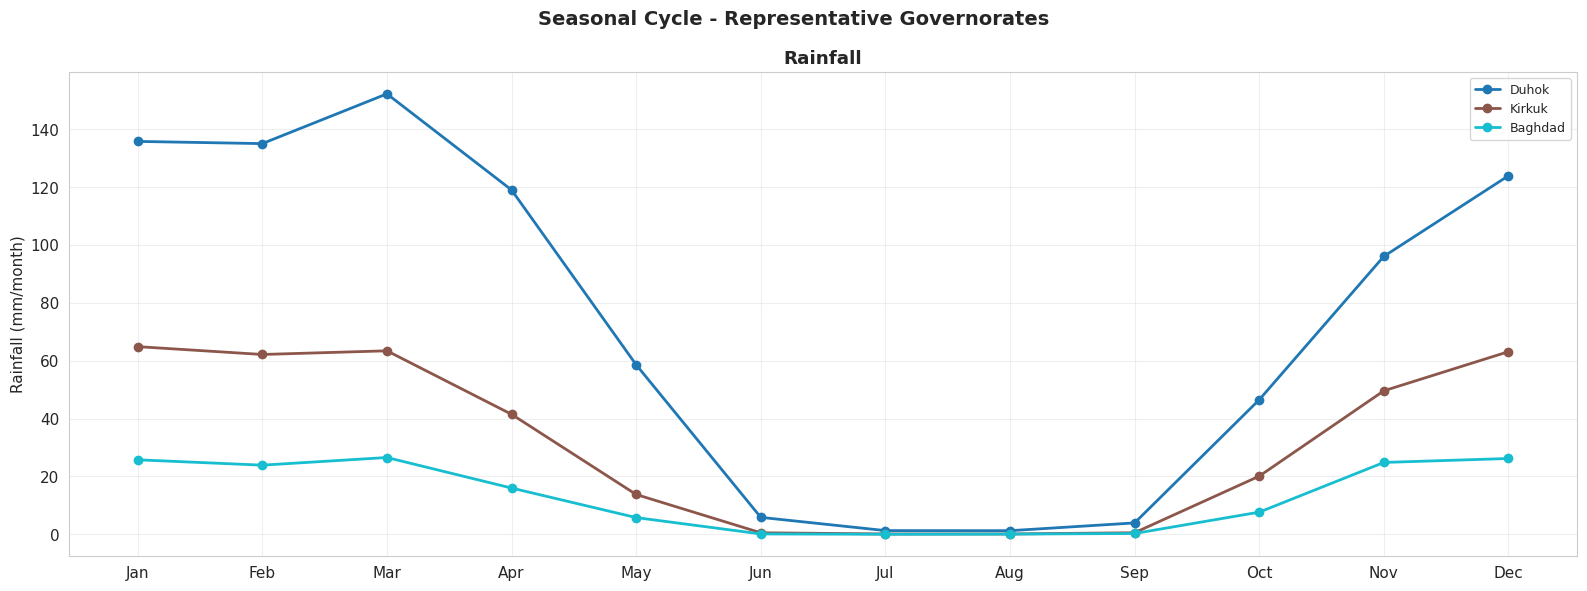

In [30]:
# =============================================================================
# SEASONAL RAINFALL PATTERNS - SELECTED GOVERNORATES
# =============================================================================

fig, axes = plt.subplots(1, 1, figsize=(16, 6))
fig.suptitle('Seasonal Cycle - Representative Governorates',
             fontsize=14, fontweight='bold')

selection = ['Duhok', 'Kirkuk', 'Baghdad']
colors = plt.cm.tab10(np.linspace(0, 1, len(selection)))

# --- Rainfall ---
ax1 = axes
for gov, color in zip(selection, colors):
    ax1.plot(range(1, 13), rain_clim[gov].values, 'o-', color=color,
             linewidth=2, markersize=6, label=gov)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names)
ax1.set_ylabel('Rainfall (mm/month)')
ax1.set_title('Rainfall', fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


--

## 7. Spatial Patterns — Mapping the Differences

> *If a GeoJSON file of Iraq’s governorates is available, we can map our results geographically.*

Place your GeoJSON file at `data/irq_admin1.geojson`. This section is **optional** — all statistical analyses above are complete without it.

📍 GeoJSON loaded: 18 features


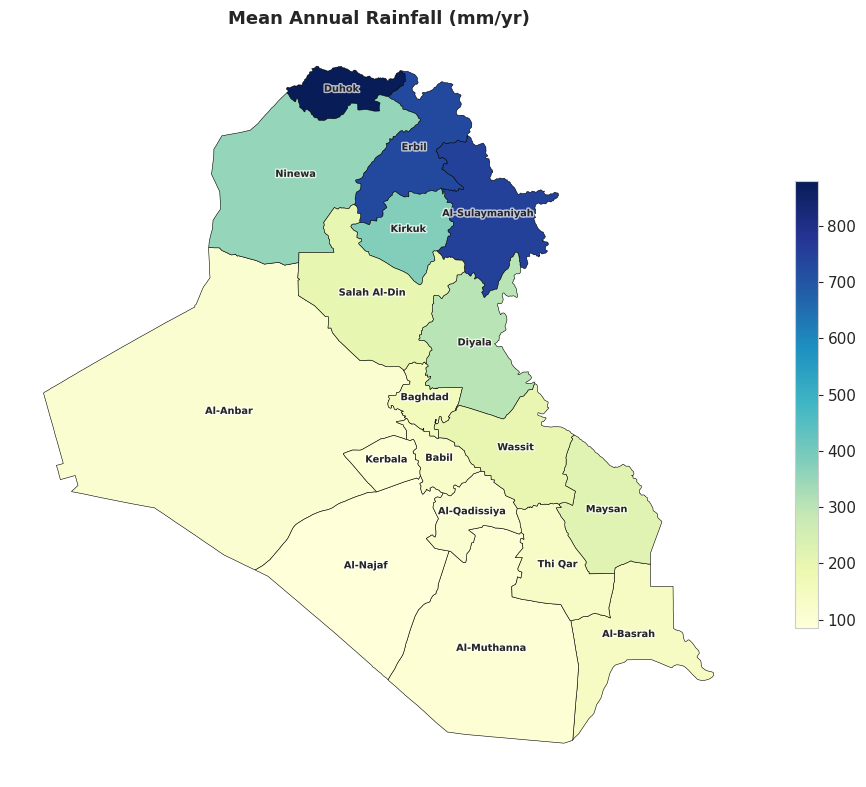

In [31]:
# =============================================================================
# SPATIAL MAPPING (requires geopandas + GeoJSON)
# =============================================================================

import matplotlib.patheffects as pe

geojsoN_file = os.path.join(data_folder, 'irq_admin1.geojson')

if GPD_AVAILABLE and os.path.exists(geojson_file):
    gdf = gpd.read_file(geojson_file)

    print(f"📍 GeoJSON loaded: {len(gdf)} features")

    # Find the name column
    name_col = 'adm1_name' if 'adm1_name' in gdf.columns else None

    if name_col:
        # Prepare data for mapping only Mean Rainfall from rain_stats
        # Create a DataFrame directly from rain_stats for merging
        rainfall_map_df = rain_stats[['Mean (mm/yr)']].reset_index()
        rainfall_map_df.columns = ['governorate', 'Mean_Rainfall']

        gdf_merged = gdf.merge(rainfall_map_df, left_on=name_col, right_on='governorate', how='left')

        fig, ax = plt.subplots(1, 1, figsize=(10, 8)) # Single subplot

        # Plot only Mean_Rainfall
        gdf_merged.plot(column='Mean_Rainfall', cmap='YlGnBu', legend=True,
                       ax=ax, edgecolor='black', linewidth=0.4,
                       missing_kwds={'color': 'lightgray'},
                       legend_kwds={'shrink': 0.6})

        # Add labels using 'adm1_name'
        for x, y, label in zip(gdf_merged.geometry.centroid.x, gdf_merged.geometry.centroid.y, gdf_merged[name_col]):
            ax.text(x, y, label, fontsize=7, ha='center', fontweight='bold',
                    path_effects=[pe.withStroke(linewidth=2, foreground='white', alpha=0.7)])

        ax.set_title('Mean Annual Rainfall (mm/yr)', fontweight='bold', fontsize=13)
        ax.axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Could not find 'adm1_name' column in GeoJSON")
else:
    print("ℹ️ Spatial mapping skipped (geopandas missing or GeoJSON not found)")

---

## 8. Summary Key Findings